In [ ]:
import kagglehub
path = kagglehub.dataset_download('nih-chest-xrays/data')
print('Path to dataset files:', path)

100%|██████████| 42.0G/42.0G [31:50<00:00, 23.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


In [ ]:
import os
from glob import glob

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
from tqdm import tqdm
import cv2
from PIL import Image
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

import torch
from torch import optim, nn
import torch.nn.functional as F
from torchvision import transforms as T, models
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.benchmark = True  # Auto-tune for faster convolutions
torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed

# Enable TF32 for A100 Tensor Cores (significant speedup)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'TF32 enabled: {torch.backends.cuda.matmul.allow_tf32}')


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB
TF32 enabled: True


### Load data

In [ ]:
all_image_paths = {
    os.path.basename(p): p for p in glob(f'{path}/images_*/images/*.png')
}
print('Images found:', len(all_image_paths))

labels = pd.read_csv(f'{path}/Data_Entry_2017.csv')
labels.rename(columns={'Follow-up #' : 'follow_up', 'OriginalImage[Width': 'OriginalImageWidth', 'Height]': 'OriginalImageHeight', 'OriginalImagePixelSpacing[x': 'OriginalImagePixelSpacing_x', 'y]': 'OriginalImagePixelSpacing_y'}, inplace=True)
labels.columns = [
    re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col).capitalize().replace(' ', '_')
    for col in labels.columns
]
labels = labels[['Image_index', 'Finding_labels', 'Follow_up', 'Patient_id', 'Patient_age', 'Patient_gender', 'View_position']]

labels.loc[labels['Patient_age'] > 100, 'Patient_age'] = np.nan #Min: 148, Max: 414 yrs old
labels['Patient_age'] = labels.groupby('Patient_id')['Patient_age'].ffill().bfill()

label_cols = labels['Finding_labels'].str.get_dummies(sep='|')
labels = pd.concat([labels, label_cols], axis=1)
labels['Finding_labels'] = np.where(labels['Finding_labels'] == 'No Finding', 0, 1)
# labels.drop(columns=['Finding_labels'], inplace=True)
labels.rename(columns={'No Finding': 'No_Finding'}, inplace=True)
labels.sort_values(by=['Patient_id', 'Follow_up'], inplace=True)
labels.head()

Images found: 112120


,Image_index,Finding_labels,Follow_up,Patient_id,Patient_age,Patient_gender,View_position,Atelectasis,Cardiomegaly,Consolidation,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No_Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,1,0,1,58.0,M,PA,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,1,1,1,58.0,M,PA,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,1,2,1,58.0,M,PA,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,0,0,2,81.0,M,PA,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,1,0,3,81.0,F,PA,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Random split
# patient_ids = labels['Patient_id'].unique()
# np.random.shuffle(patient_ids)

# n_train = int(len(patient_ids) * 0.8)
# train_patients = patient_ids[: n_train]
# test_patients = patient_ids[n_train :]

# train_labels = labels[labels['Patient_id'].isin(train_patients)].reset_index(drop=True)
# test_labels = labels[labels['Patient_id'].isin(test_patients)].reset_index(drop=True)

with open(f'{path}/train_val_list.txt', 'r') as file:
    train_list = file.read().split('\n')

with open(f'{path}/test_list.txt', 'r') as file:
    test_list = file.read().split('\n')

train_labels = labels.loc[labels['Image_index'].isin(train_list)].copy()
test_labels = labels.loc[labels['Image_index'].isin(test_list)].copy()

print(f'Train shape: {train_labels.shape}')
print(f'Test shape: {test_labels.shape}')
assert set(train_labels['Patient_id']).isdisjoint(test_labels['Patient_id'])

Train shape: (86524, 22)
Test shape: (25596, 22)


In [ ]:
# Basic dataset information
print('=== Basic Dataset Information ===')
print(f'Total number of images: {len(labels)}')
print(f'Total number of unique patients: {labels['Patient_id'].nunique()}')
print(f'Dataset shape: {labels.shape}')

print('\n=== Train Set Information ===')
print(f'Number of images (train): {len(train_labels)}')
print(f'Number of unique patients (train): {train_labels['Patient_id'].nunique()}')
print(f'Train set shape: {train_labels.shape}')

print('\n=== Test Set Information ===')
print(f'Number of images (test): {len(test_labels)}')
print(f'Number of unique patients (test): {test_labels['Patient_id'].nunique()}')
print(f'Test set shape: {test_labels.shape}')

=== Basic Dataset Information ===
Total number of images: 112120
Total number of unique patients: 30805
Dataset shape: (112120, 22)

=== Train Set Information ===
Number of images (train): 86524
Number of unique patients (train): 28008
Train set shape: (86524, 22)

=== Test Set Information ===
Number of images (test): 25596
Number of unique patients (test): 2797
Test set shape: (25596, 22)


In [ ]:
disease_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Class distributions
disease_counts_train = train_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_train = train_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)
disease_counts_test = test_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_test = test_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)

# Percentage of disease labels on train data
disease_pct = (disease_counts_include_nf_train / len(train_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')

# Percentage of disease labels on test data
disease_pct = (disease_counts_include_nf_test / len(test_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')


Disease prevalence (%):
No_Finding            58.37
Infiltration          15.93
Effusion              10.01
Atelectasis            9.57
Nodule                 5.44
Mass                   4.66
Consolidation          3.30
Pneumothorax           3.05
Pleural_Thickening     2.59
Cardiomegaly           1.97
Emphysema              1.64
Edema                  1.59
Fibrosis               1.45
Pneumonia              1.01
Hernia                 0.16
dtype: float64

Disease prevalence (%):
No_Finding            38.53
Infiltration          23.88
Effusion              18.20
Atelectasis           12.81
Pneumothorax          10.41
Consolidation          7.09
Mass                   6.83
Nodule                 6.34
Pleural_Thickening     4.47
Emphysema              4.27
Cardiomegaly           4.18
Edema                  3.61
Pneumonia              2.17
Fibrosis               1.70
Hernia                 0.34
dtype: float64


In [ ]:
# def create_balanced_subset(df, disease_cols, samples_per_class=100, min_total=2000):
#     selected_indices = set()

#     for col in disease_cols:
#         positive_indices = df[df[col] == 1].index.tolist()
#         n_select = min(samples_per_class, len(positive_indices))
#         selected_indices.update(np.random.choice(positive_indices, n_select, replace=False))

#     remaining_indices = list(set(df.index) - selected_indices)
#     n_remaining = max(0, min_total - len(selected_indices))
#     if n_remaining > 0 and len(remaining_indices) > 0:
#         additional = np.random.choice(remaining_indices, min(n_remaining, len(remaining_indices)), replace=False)
#         selected_indices.update(additional)

#     subset_df = df.loc[list(selected_indices)].reset_index(drop=True)
#     return subset_df

# # Train test subset
# train_labels_subset = create_balanced_subset(train_labels, disease_cols, samples_per_class=150, min_total=3000)
# test_labels_subset = create_balanced_subset(test_labels, disease_cols, samples_per_class=50, min_total=800)

# print('=== Train Subset ===')
# print(f'Total samples: {len(train_labels_subset)}')
# print('Samples per class:')
# print(train_labels_subset[disease_cols].sum().to_string())

# print('\n=== Test Subset ===')
# print(f'Total samples: {len(test_labels_subset)}')
# print('Samples per class:')
# print(test_labels_subset[disease_cols].sum().to_string())

# train_labels = train_labels_subset
# test_labels = test_labels_subset

### Preprocessing

In [ ]:
IMG_SIZE = 384

class ImageDataset(Dataset):
    def __init__(self, data, image_paths, label_cols, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_paths = image_paths
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_name = self.data.iloc[index]['Image_index']
        img_path = self.image_paths.get(img_name)

        if img_path is None:
            raise FileNotFoundError(f'Image not found: {img_name}')

        img = Image.open(img_path).convert('RGB')
        label = self.data.iloc[index][self.label_cols].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# train_transform = T.Compose([
#     T.Resize((IMG_SIZE, IMG_SIZE)),
#     T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
#     T.RandomRotation(15),
#     T.ColorJitter(brightness=0.2, contrast=0.2),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     T.RandomErasing(p=0.1, scale=(0.02, 0.1))
# ])

# test_transform = T.Compose([
#     T.Resize((256, 256)),
#     T.CenterCrop(224),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train = ImageDataset(train_labels, image_paths=all_image_paths, label_cols=disease_cols, transform=train_transform)
test = ImageDataset(test_labels, image_paths=all_image_paths, label_cols=disease_cols, transform=test_transform)
print(f'Length of trainset: {len(train)}')
print(f'Length of testset: {len(test)}')
print(f'Number of classes: {len(disease_cols)}')
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')

Length of trainset: 86524
Length of testset: 25596
Number of classes: 14
Image size: 384x384


Text(0.5, 1.0, 'Cardiomegaly')

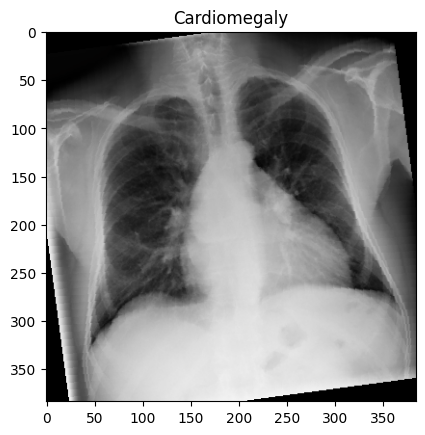

In [ ]:
def deprocess(img):
    img = img.permute(1,2,0) #(C, H, W) -> (H, W, C) for ploting matplotlib
    img = img * torch.Tensor([0.229, 0.224, 0.225]) + torch.Tensor([0.485, 0.456, 0.406])
    return img

image, label = train[0]
class_labels = list(np.where(label==1)[0])
plt.imshow(deprocess(image))
plt.title(', '.join([disease_cols[i] for i in class_labels]))

In [ ]:
NUM_WORKERS = 8
PIN_MEMORY = torch.cuda.is_available()
BATCH_SIZE = 256

def get_sample_weights(labels_df, disease_cols):
    """
    Calculate sample weights for WeightedRandomSampler
    Samples with rare diseases get higher weights
    """
    # Class frequencies (inverse)
    class_counts = labels_df[disease_cols].sum(axis=0).values
    total_samples = len(labels_df)
    class_weights = total_samples / (class_counts + 1e-6)

    # Normalize weights
    class_weights = class_weights / class_weights.sum() * len(disease_cols)

    # Sample weight = max weight of its positive labels (or 1 if no positive)
    sample_weights = []
    for idx in range(len(labels_df)):
        row_labels = labels_df.iloc[idx][disease_cols].values
        positive_indices = np.where(row_labels == 1)[0]

        if len(positive_indices) > 0:
            weight = max(class_weights[positive_indices])
        else:
            weight = 1.0
        sample_weights.append(weight)

    return torch.DoubleTensor(sample_weights)

sample_weights = get_sample_weights(train_labels, disease_cols)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
print(f'Sample weights - Min: {sample_weights.min():.4f}, Max: {sample_weights.max():.4f}, Mean: {sample_weights.mean():.4f}')

train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=False, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=True if NUM_WORKERS > 0 else False,
                          prefetch_factor=2)
test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                         persistent_workers=True if NUM_WORKERS > 0 else False,
                         prefetch_factor=2)

print(f'\n=== A100 HighVRAM DataLoader Config ===')
print(f'Batch size: {BATCH_SIZE}')
print(f'Num workers: {NUM_WORKERS}')
print(f'Pin memory: {PIN_MEMORY}')

Sample weights - Min: 0.0782, Max: 7.6422, Mean: 0.7254

=== A100 HighVRAM DataLoader Config ===
Batch size: 256
Num workers: 8
Pin memory: True


### Model

In [ ]:
class Net(nn.Module):
    def __init__(self, num_classes=14, dropout_rate=0.3):
        super(Net, self).__init__()
        self.densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        for param in list(self.densenet.parameters())[:-30]:
            param.requires_grad = False

        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.densenet(x)

model = Net(num_classes=len(disease_cols), dropout_rate=0.3).to(device)
print(f'Model: DenseNet121')
print(f'Model loaded on: {device}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 210MB/s]


Model: DenseNet121
Model loaded on: cuda
Total parameters: 7,615,118
Trainable parameters: 1,339,662


### Training

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, pos_weight=None, label_smoothing=0.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Label smoothing for noisy labels
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + self.label_smoothing / 2

        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets,
            pos_weight=self.pos_weight,
            reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        return focal_loss.mean()

def weighted_loss(pos_weights, neg_weights, y_pred, y_true, epsilon=1e-7):
    loss = 0.0
    for i in range(len(pos_weights)):
        loss_pos = -1 * torch.mean(pos_weights[i] * y_true[:,i] * torch.log(y_pred[:,i] + epsilon))
        loss_neg = -1 * torch.mean(neg_weights[i] * (1-y_true[:,i]) * torch.log((1-y_pred[:,i]) + epsilon))
        loss += loss_pos + loss_neg
    return loss

In [ ]:
# ==================== TRAINING CONFIGURATION ====================
epochs = 30
n_folds = 3
batch_size = BATCH_SIZE
learning_rate = 6e-4
weight_decay = 1e-4
label_smoothing = 0.1

scaler = GradScaler('cuda') if torch.cuda.is_available() else None
use_amp = torch.cuda.is_available()

# Using WeightedRandomSampler instead for class balancing
freq = train_labels[disease_cols].sum(axis=0).values
total = len(train_labels)
# pos_weight = torch.tensor((total - freq) / (freq + 1e-6), dtype=torch.float32, device=device)
# print('Class weights (pos_weight):')
# for i, col in enumerate(disease_cols):
#     print(f'  {col}: {pos_weight[i].item():.2f}')
print('NOTE: pos_weight DISABLED - using Focal Loss + WeightedRandomSampler instead')
print(f'Class frequencies:')
for i, col in enumerate(disease_cols):
    print(f'  {col}: {freq[i]} ({freq[i]/total*100:.2f}%)')

groups = train_labels['Patient_id'].values
gkf = GroupKFold(n_splits=5)

train_losses = []
val_losses = []
val_aucs = []
best_models = []

print(f'\n=== Training Configuration (A100 HighVRAM) ===')
print(f'Epochs: {epochs}')
print(f'Folds: {n_folds}')
print(f'Batch size: {batch_size}')
print(f'Learning rate: {learning_rate}')
print(f'Weight decay: {weight_decay}')
print(f'Label smoothing: {label_smoothing}')
print(f'Mixed Precision (AMP): {use_amp}')
print(f'TF32 enabled: {torch.backends.cuda.matmul.allow_tf32}')
print(f'Loss: Focal Loss (alpha=1, gamma=2, NO pos_weight)\n')

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_labels, groups=groups)):
    if fold >= n_folds:
        break

    print(f'\n{'='*25} Fold {fold + 1}/{n_folds} {'='*25}')

    train_subset = Subset(train, train_idx)
    val_subset = Subset(train, val_idx)

    # Create WeightedRandomSampler for train subset
    subset_weights = sample_weights[train_idx]
    fold_sampler = WeightedRandomSampler(
        weights=subset_weights,
        num_samples=len(subset_weights),
        replacement=True
    )

    loader_train = DataLoader(train_subset, batch_size=batch_size, shuffle=False,
                              sampler=fold_sampler,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=True if NUM_WORKERS > 0 else False,
                              prefetch_factor=2)
    loader_val = DataLoader(val_subset, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                            persistent_workers=True if NUM_WORKERS > 0 else False,
                            prefetch_factor=2)

    print(f'Train size: {len(train_subset)}, Val size: {len(val_subset)}')

    model = Net(num_classes=len(disease_cols), dropout_rate=0.3).to(device)

    criterion = FocalLoss(alpha=1, gamma=2, pos_weight=None, label_smoothing=label_smoothing)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    iters_per_epoch = len(loader_train)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=iters_per_epoch * 10, T_mult=2, eta_min=1e-6
    )

    valid_loss_min = np.inf
    best_val_auc = 0.0
    fold_train_losses = []
    fold_val_losses = []
    fold_val_aucs = []
    patience_counter = 0
    early_stop_patience = 5

    global_step = 0

    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]['lr']

        # ========== Training ==========
        model.train()
        train_loss = 0.0

        train_pbar = tqdm(loader_train, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Train]')
        for batch_idx, (images, labels_batch) in enumerate(train_pbar):
            images = images.to(device, non_blocking=True)
            labels_batch = labels_batch.float().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels_batch)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            scheduler.step(epoch + batch_idx / iters_per_epoch)
            current_lr = optimizer.param_groups[0]['lr']

            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})
            global_step += 1

        avg_train_loss = train_loss / len(loader_train)
        fold_train_losses.append(avg_train_loss)

        # ========== Validation ==========
        model.eval()
        valid_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            val_pbar = tqdm(loader_val, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Val]')
            for images, labels_batch in val_pbar:
                images = images.to(device, non_blocking=True)
                labels_batch = labels_batch.float().to(device, non_blocking=True)

                if use_amp:
                    with autocast('cuda'):
                        outputs = model(images)
                        loss = criterion(outputs, labels_batch)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels_batch)

                valid_loss += loss.item()

                preds = torch.sigmoid(outputs)
                all_preds.append(preds.cpu())
                all_labels.append(labels_batch.cpu())

                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_valid_loss = valid_loss / len(loader_val)
        fold_val_losses.append(avg_valid_loss)

        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        val_acc = ((all_preds >= 0.5) == all_labels).mean() * 100

        try:
            val_auc = roc_auc_score(all_labels, all_preds, average='macro') * 100
        except:
            val_auc = 0.0
        fold_val_aucs.append(val_auc)

        if val_auc > best_val_auc:
            print(f'=> Val AUC improved ({best_val_auc:.2f}% -> {val_auc:.2f}%). Saving model...')
            torch.save({
                'fold': fold,
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'valid_loss': avg_valid_loss,
                'val_auc': val_auc,
                'val_accuracy': val_acc
            }, f'model_fold{fold+1}.pt')
            best_val_auc = val_auc
            valid_loss_min = avg_valid_loss
            patience_counter = 0
        else:
            patience_counter += 1

        print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f} | Val Loss = {avg_valid_loss:.6f} | Val Acc = {val_acc:.2f}% | Val AUC = {val_auc:.2f}% | LR = {current_lr:.2e}')

        if patience_counter >= early_stop_patience:
            print(f'Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)')
            break

    train_losses.append(fold_train_losses)
    val_losses.append(fold_val_losses)
    val_aucs.append(fold_val_aucs)
    best_models.append(f'model_fold{fold+1}.pt')

    # Clear GPU cache between folds
    torch.cuda.empty_cache()

print('\nTraining completed!')
print(f'Best models saved: {best_models}')
print(f'Best validation AUC: {best_val_auc:.2f}%')

NOTE: pos_weight DISABLED - using Focal Loss + WeightedRandomSampler instead
Class frequencies:
  Atelectasis: 8280 (9.57%)
  Cardiomegaly: 1707 (1.97%)
  Consolidation: 2852 (3.30%)
  Edema: 1378 (1.59%)
  Effusion: 8659 (10.01%)
  Emphysema: 1423 (1.64%)
  Fibrosis: 1251 (1.45%)
  Hernia: 141 (0.16%)
  Infiltration: 13782 (15.93%)
  Mass: 4034 (4.66%)
  Nodule: 4708 (5.44%)
  Pleural_Thickening: 2242 (2.59%)
  Pneumonia: 876 (1.01%)
  Pneumothorax: 2637 (3.05%)

=== Training Configuration (A100 HighVRAM) ===
Epochs: 30
Folds: 3
Batch size: 256
Learning rate: 0.0006
Weight decay: 0.0001
Label smoothing: 0.1
Mixed Precision (AMP): True
TF32 enabled: True
Loss: Focal Loss (alpha=1, gamma=2, NO pos_weight)


========================= Fold 1/3 =========================
Train size: 69219, Val size: 17305


Fold 1 | Epoch 1/30 [Train]: 100%|██████████| 271/271 [04:59<00:00,  1.11s/it, loss=0.0348, lr=6.00e-04]
Fold 1 | Epoch 1/30 [Val]: 100%|██████████| 68/68 [01:19<00:00,  1.16s/it, loss=0.0636]


=> Val AUC improved (0.00% -> 74.01%). Saving model...
Epoch 1: Train Loss = 0.042826 | Val Loss = 0.052732 | Val Acc = 95.56% | Val AUC = 74.01% | LR = 6.00e-04


Fold 1 | Epoch 2/30 [Train]: 100%|██████████| 271/271 [05:00<00:00,  1.11s/it, loss=0.0388, lr=6.00e-04]
Fold 1 | Epoch 2/30 [Val]: 100%|██████████| 68/68 [01:22<00:00,  1.21s/it, loss=0.0561]


=> Val AUC improved (74.01% -> 76.12%). Saving model...
Epoch 2: Train Loss = 0.034618 | Val Loss = 0.049778 | Val Acc = 95.49% | Val AUC = 76.12% | LR = 6.00e-04


...

Epoch 10: Train Loss = 0.028733 | Val Loss = 0.051468 | Val Acc = 95.53% | Val AUC = 77.31% | LR = 6.00e-04


Fold 3 | Epoch 11/30 [Train]: 100%|██████████| 271/271 [04:54<00:00,  1.09s/it, loss=0.0239, lr=6.00e-04]
Fold 3 | Epoch 11/30 [Val]: 100%|██████████| 68/68 [01:17<00:00,  1.14s/it, loss=0.0695]


Epoch 11: Train Loss = 0.028431 | Val Loss = 0.052157 | Val Acc = 95.50% | Val AUC = 77.67% | LR = 6.00e-04


Fold 3 | Epoch 12/30 [Train]: 100%|██████████| 271/271 [04:55<00:00,  1.09s/it, loss=0.0249, lr=6.00e-04]
Fold 3 | Epoch 12/30 [Val]: 100%|██████████| 68/68 [01:18<00:00,  1.15s/it, loss=0.0693]

Epoch 12: Train Loss = 0.027819 | Val Loss = 0.051175 | Val Acc = 95.40% | Val AUC = 77.32% | LR = 6.00e-04
Early stopping at epoch 12 (no improvement for 5 epochs)

Training completed!
Best models saved: ['model_fold1.pt', 'model_fold2.pt', 'model_fold3.pt']
Best validation AUC: 77.74%


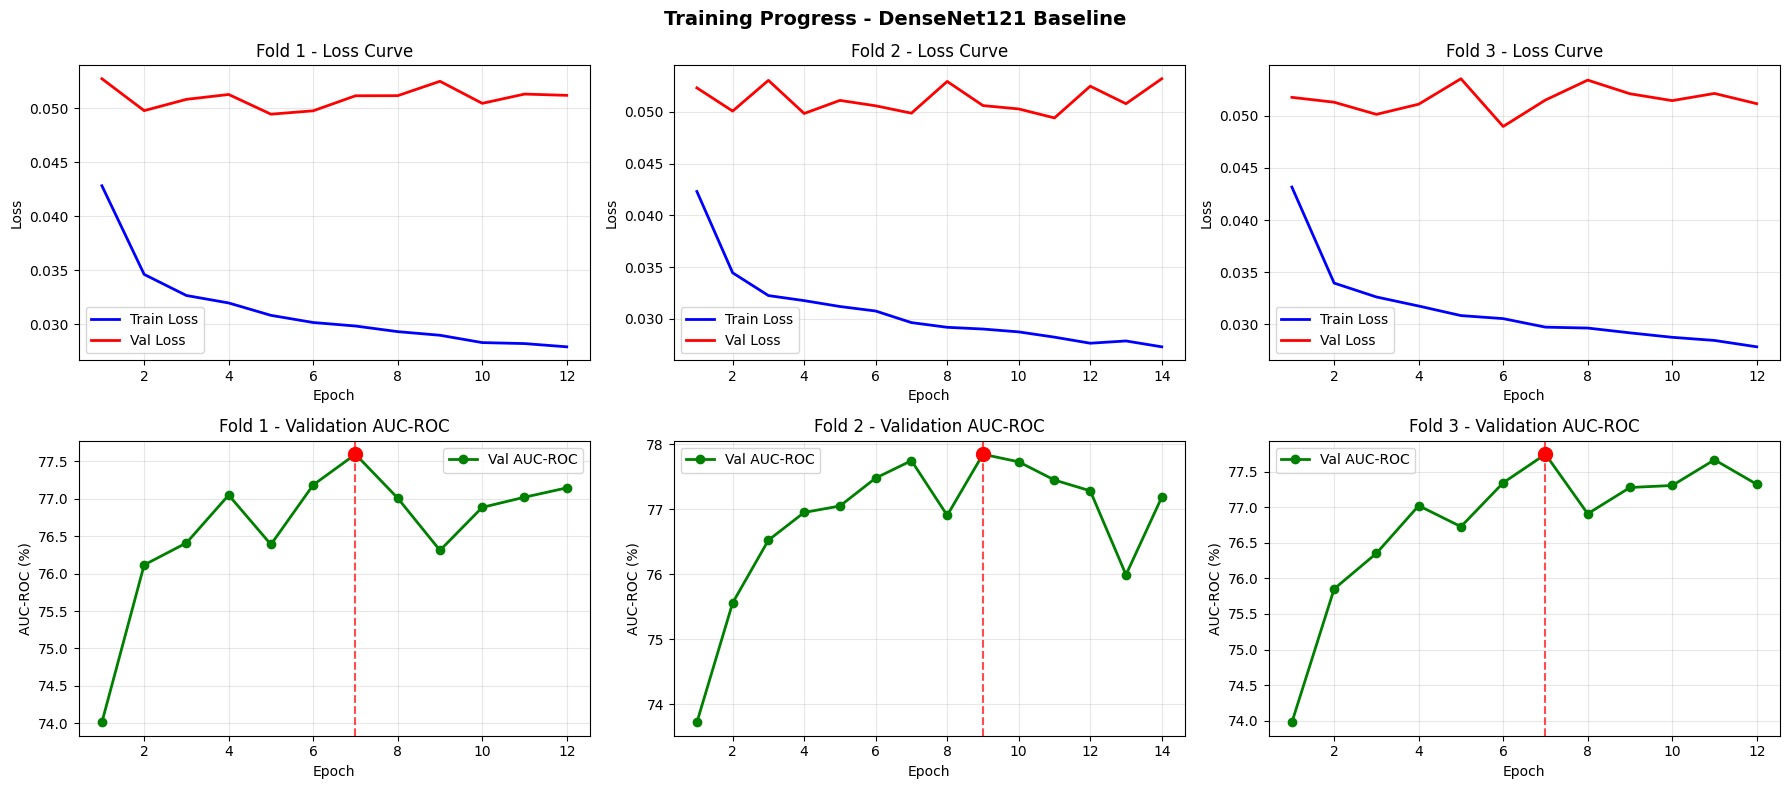

Best validation AUC across folds: 77.85%


In [ ]:
fig, axes = plt.subplots(2, len(train_losses), figsize=(6*len(train_losses), 8))
if len(train_losses) == 1:
    axes = axes.reshape(2, 1)

for i, (train_loss, val_loss, val_auc) in enumerate(zip(train_losses, val_losses, val_aucs)):
    # Loss curve
    axes[0, i].plot(range(1, len(train_loss)+1), train_loss, 'b-', label='Train Loss', linewidth=2)
    axes[0, i].plot(range(1, len(val_loss)+1), val_loss, 'r-', label='Val Loss', linewidth=2)
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Fold {i+1} - Loss Curve')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    # AUC curve
    axes[1, i].plot(range(1, len(val_auc)+1), val_auc, 'g-', label='Val AUC-ROC', linewidth=2, marker='o')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('AUC-ROC (%)')
    axes[1, i].set_title(f'Fold {i+1} - Validation AUC-ROC')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch = np.argmax(val_auc) + 1
    best_auc = max(val_auc)
    axes[1, i].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_auc:.2f}%')
    axes[1, i].scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)

plt.suptitle('Training Progress - DenseNet121 Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best validation AUC across folds: {max([max(auc) for auc in val_aucs]):.2f}%')

In [ ]:
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

def find_optimal_thresholds(all_labels, all_preds, disease_cols, min_precision=0.15):
    optimal_thresholds = {}
    threshold_results = []

    for i, col in enumerate(disease_cols):
        y_true = all_labels[:, i]
        y_pred = all_preds[:, i]

        best_f1 = 0
        best_threshold = 0.5
        best_metrics = {}

        for thresh in np.arange(0.1, 0.61, 0.02):
            pred_binary = (y_pred >= thresh).astype(int)

            # Calculate metrics
            precision = precision_score(y_true, pred_binary, zero_division=0)
            recall = recall_score(y_true, pred_binary, zero_division=0)
            f1 = f1_score(y_true, pred_binary, zero_division=0)

            if precision >= min_precision and f1 > best_f1:
                best_f1 = f1
                best_threshold = thresh
                best_metrics = {
                    'precision': precision,
                    'recall': recall,
                    'f1': f1
                }

        optimal_thresholds[col] = best_threshold
        threshold_results.append({
            'Disease': col,
            'Optimal_Threshold': round(best_threshold, 2),
            'F1': round(best_metrics.get('f1', 0) * 100, 2),
            'Precision': round(best_metrics.get('precision', 0) * 100, 2),
            'Recall': round(best_metrics.get('recall', 0) * 100, 2)
        })

    df_thresholds = pd.DataFrame(threshold_results)
    return optimal_thresholds, df_thresholds


def evaluate_model(dataloader, model, disease_cols, threshold=0.5, thresholds_dict=None, dataset_name='Dataset'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'Evaluating {dataset_name}'):
            images = images.to(device, non_blocking=True)

            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
            else:
                outputs = model(images)

            preds = torch.sigmoid(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Per-class comprehensive metrics
    results = []
    for i, col in enumerate(disease_cols):
        if thresholds_dict is not None:
            thresh = thresholds_dict.get(col, threshold)
        else:
            thresh = threshold

        pred_binary = (all_preds[:, i] >= thresh).astype(int)
        true_labels = all_labels[:, i].astype(int)

        tp = ((pred_binary == 1) & (true_labels == 1)).sum()
        tn = ((pred_binary == 0) & (true_labels == 0)).sum()
        fp = ((pred_binary == 1) & (true_labels == 0)).sum()
        fn = ((pred_binary == 0) & (true_labels == 1)).sum()

        accuracy = (pred_binary == true_labels).mean() * 100

        try:
            auc = roc_auc_score(true_labels, all_preds[:, i]) * 100
        except:
            auc = 0.0

        precision = precision_score(true_labels, pred_binary, zero_division=0) * 100
        recall = recall_score(true_labels, pred_binary, zero_division=0) * 100
        f1 = f1_score(true_labels, pred_binary, zero_division=0) * 100

        results.append({
            'Disease': col,
            'Threshold': round(thresh, 2),
            'Accuracy': round(accuracy, 2),
            'AUC-ROC': round(auc, 2),
            'Precision': round(precision, 2),
            'Recall': round(recall, 2),
            'F1-Score': round(f1, 2),
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Total_Positive': int(true_labels.sum()),
            'Predicted_Positive': int(pred_binary.sum())
        })

    df_results = pd.DataFrame(results)

    # Overall metrics
    print(f'\n{'='*60}')
    print(f'{dataset_name.upper()} EVALUATION RESULTS')
    print(f'{'='*60}')
    print(f'Threshold mode: {"Per-class optimal" if thresholds_dict else f"Fixed ({threshold})"}')
    print(f'Mean AUC-ROC: {df_results["AUC-ROC"].mean():.2f}%')
    print(f'Mean F1-Score: {df_results["F1-Score"].mean():.2f}%')
    print(f'Mean Precision: {df_results["Precision"].mean():.2f}%')
    print(f'Mean Recall: {df_results["Recall"].mean():.2f}%')
    print(f'{'='*60}\n')

    return df_results, all_preds, all_labels


def plot_threshold_analysis(all_labels, all_preds, disease_cols):
    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    axes = axes.flatten()

    for i, col in enumerate(disease_cols):
        ax = axes[i]
        y_true = all_labels[:, i]
        y_pred = all_preds[:, i]

        thresholds = np.arange(0.1, 0.7, 0.02)
        f1_scores = []
        precisions = []
        recalls = []

        for thresh in thresholds:
            pred_binary = (y_pred >= thresh).astype(int)
            f1_scores.append(f1_score(y_true, pred_binary, zero_division=0))
            precisions.append(precision_score(y_true, pred_binary, zero_division=0))
            recalls.append(recall_score(y_true, pred_binary, zero_division=0))

        ax.plot(thresholds, f1_scores, 'b-', label='F1', linewidth=2)
        ax.plot(thresholds, precisions, 'g--', label='Precision', linewidth=1.5)
        ax.plot(thresholds, recalls, 'r--', label='Recall', linewidth=1.5)

        best_idx = np.argmax(f1_scores)
        ax.axvline(thresholds[best_idx], color='blue', linestyle=':', alpha=0.7)
        ax.scatter([thresholds[best_idx]], [f1_scores[best_idx]], color='blue', s=50, zorder=5)

        ax.set_xlabel('Threshold')
        ax.set_ylabel('Score')
        ax.set_title(f'{col}', fontweight='bold')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0.1, 0.7])
        ax.set_ylim([0, 1])

    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')

    plt.suptitle('Threshold Analysis: F1, Precision, Recall per Class', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_roc_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()

    for i, col in enumerate(disease_cols):
        ax = axes[i]

        try:
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            ax.plot(fpr, tpr, 'b-', label=f'AUC = {auc:.3f}')
            ax.plot([0, 1], [0, 1], 'r--', label='Random')
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')

    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'ROC Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_precision_recall_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()

    for i, col in enumerate(disease_cols):
        ax = axes[i]

        try:
            precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
            ap = average_precision_score(all_labels[:, i], all_preds[:, i])
            ax.plot(recall, precision, 'b-', label=f'AP = {ap:.3f}')
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower left')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')

    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Precision-Recall Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def class_accuracy(dataloader, model, thresholds_dict=None, default_threshold=0.5):
    per_class_accuracy = [0 for i in range(len(disease_cols))]

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if use_amp:
                with autocast('cuda'):
                    ps = model(images)
            else:
                ps = model(images)

            ps = torch.sigmoid(ps)

            for i in range(ps.shape[1]):
                thresh = thresholds_dict.get(disease_cols[i], default_threshold) if thresholds_dict else default_threshold
                pred_binary = (ps[:, i:i+1] >= thresh).float()
                per_class_accuracy[i] += int((pred_binary == labels[:, i:i+1]).sum())

        per_class_accuracy = [(i/len(dataloader.dataset))*100.0 for i in per_class_accuracy]

    return per_class_accuracy

def get_acc_data(class_names, acc_list):
    df = pd.DataFrame(list(zip(class_names, acc_list)), columns=['Labels', 'Acc'])
    return df

LOAD MODEL & FIND OPTIMAL THRESHOLDS
Loaded model from fold 1, epoch 7
Best validation loss: 0.051153
Best validation AUC: 77.60%

--- Getting predictions for threshold tuning ---


Getting train predictions: 100%|██████████| 338/338 [06:06<00:00,  1.08s/it]



--- Finding Optimal Thresholds (min precision: 15%) ---

Optimal Thresholds per Disease:


,Disease,Optimal_Threshold,F1,Precision,Recall
0,Atelectasis,0.36,29.19,24.44,36.24
1,Cardiomegaly,0.40,36.87,31.69,44.07
2,Consolidation,0.36,15.86,16.10,15.64
3,Edema,0.44,40.45,36.68,45.08
4,Effusion,0.38,39.57,31.16,54.22
5,Emphysema,0.42,41.32,42.22,40.45
6,Fibrosis,0.30,22.61,19.20,27.48
7,Hernia,0.60,87.64,94.57,81.65
8,Infiltration,0.40,32.50,28.35,38.07
9,Mass,0.36,28.17,29.60,26.87



Mean optimal threshold: 0.384

--- Threshold Analysis Plots ---


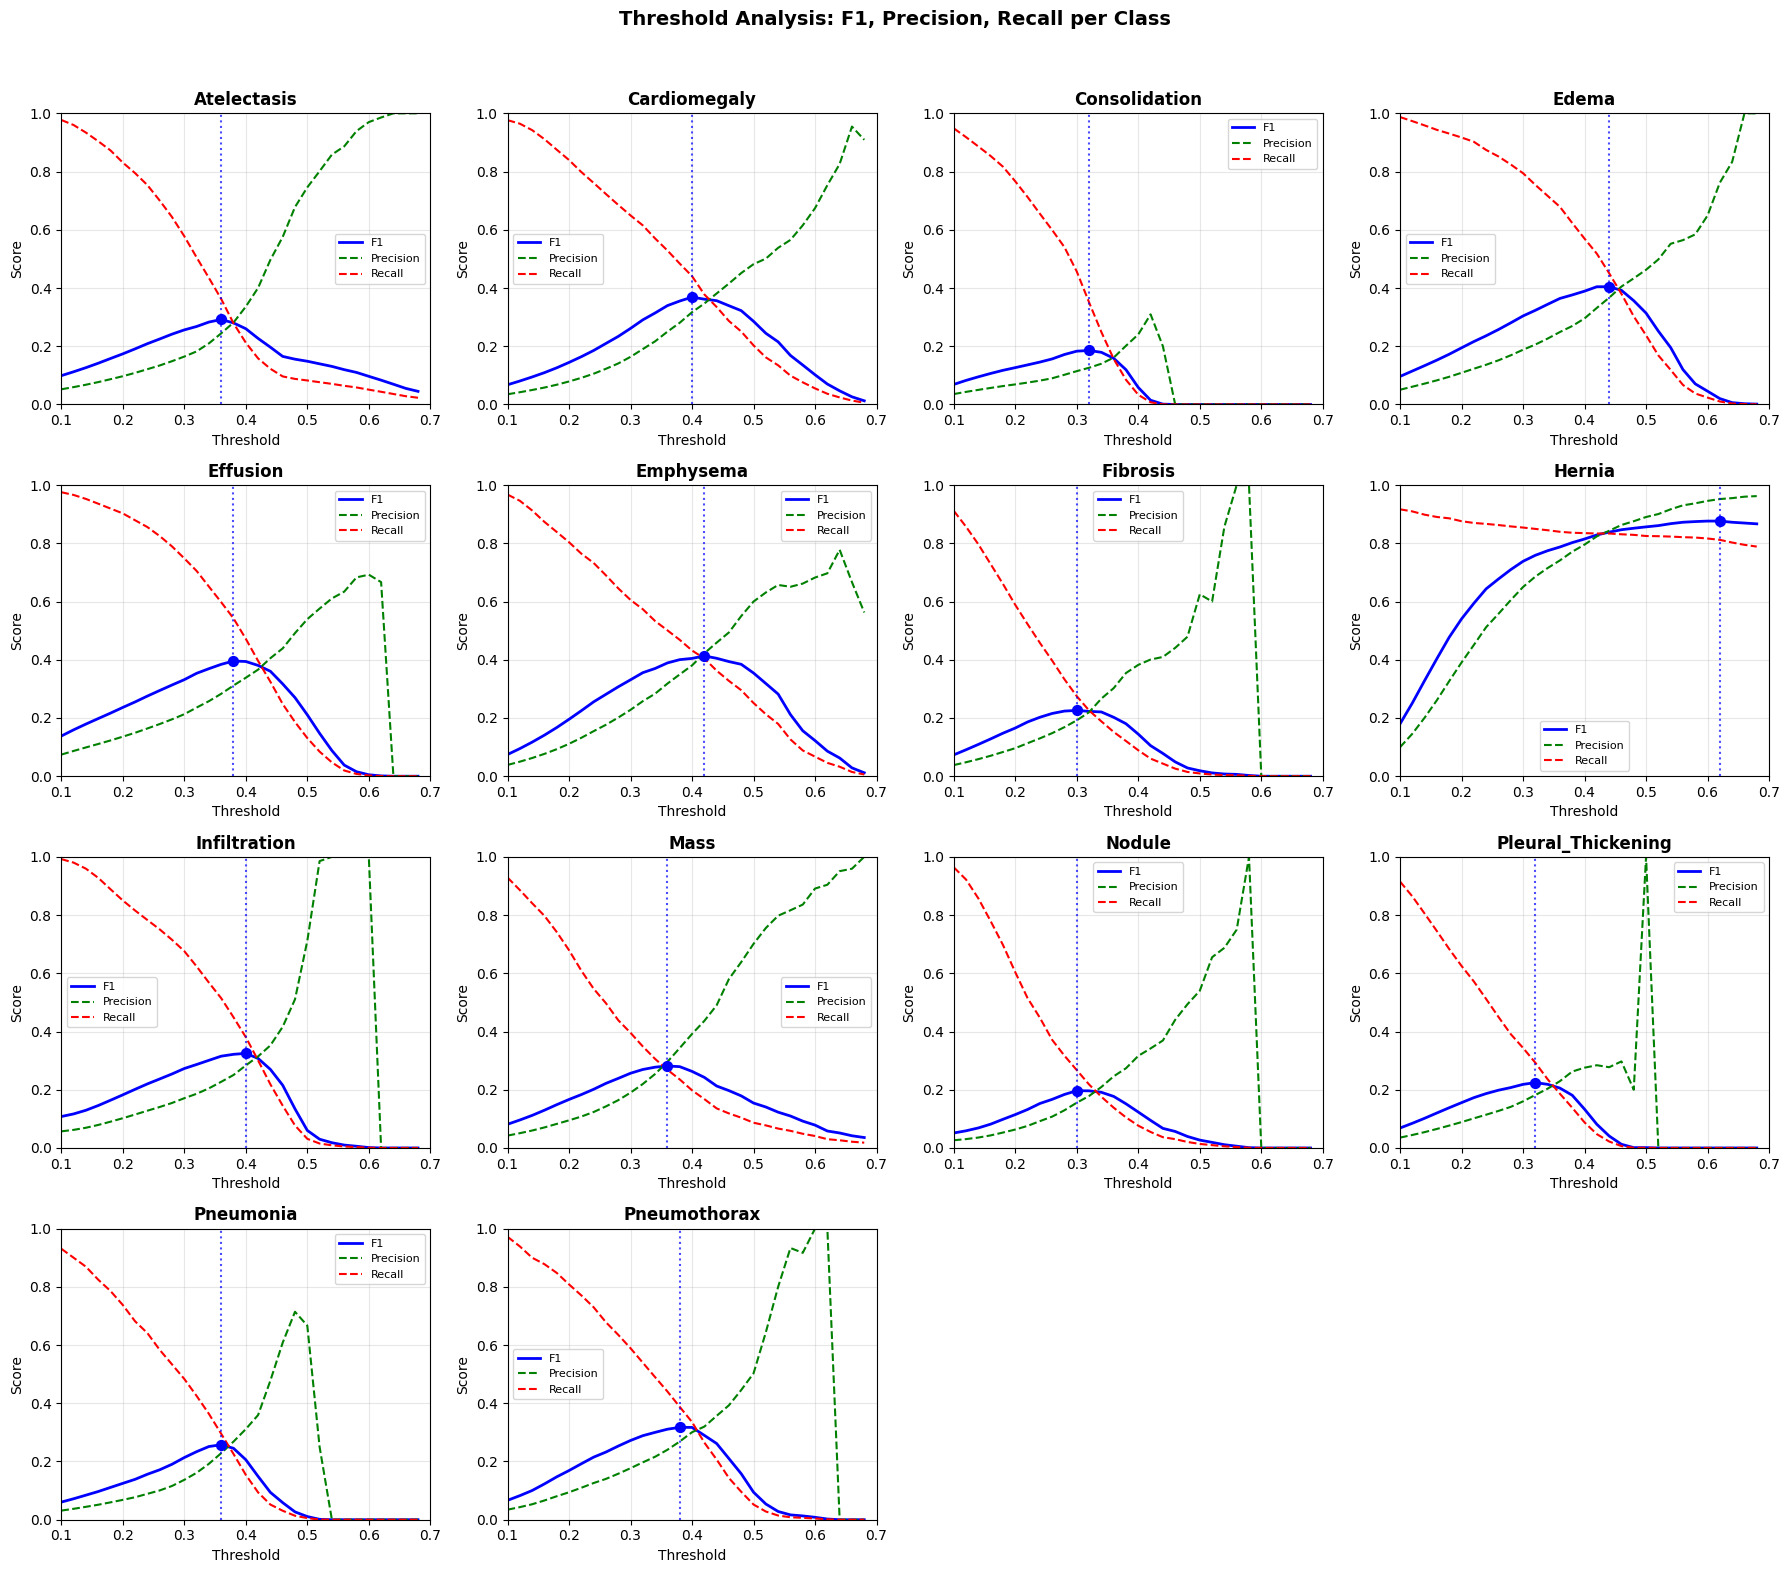

In [ ]:
# LOAD BEST MODEL & FIND OPTIMAL THRESHOLDS
print('='*60)
print('LOAD MODEL & FIND OPTIMAL THRESHOLDS')
print('='*60)

checkpoint = torch.load('model_fold1.pt', weights_only=False, map_location=device)
model = Net(num_classes=len(disease_cols), dropout_rate=0.3).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Loaded model from fold 1, epoch {checkpoint["epoch"]+1}')
print(f'Best validation loss: {checkpoint["valid_loss"]:.6f}')
print(f'Best validation AUC: {checkpoint["val_auc"]:.2f}%')


print('\n--- Getting predictions for threshold tuning ---')
model.eval()
all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for images, labels_batch in tqdm(train_loader, desc='Getting train predictions'):
        images = images.to(device, non_blocking=True)
        if use_amp:
            with autocast('cuda'):
                outputs = model(images)
        else:
            outputs = model(images)
        preds = torch.sigmoid(outputs)
        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels_batch.numpy())

all_train_preds = np.vstack(all_train_preds)
all_train_labels = np.vstack(all_train_labels)

print('\n--- Finding Optimal Thresholds (min precision: 15%) ---')
optimal_thresholds, threshold_df = find_optimal_thresholds(
    all_train_labels, all_train_preds, disease_cols, min_precision=0.15
)
print('\nOptimal Thresholds per Disease:')
display(threshold_df)

print(f'\nMean optimal threshold: {np.mean(list(optimal_thresholds.values())):.3f}')

print('\n--- Threshold Analysis Plots ---')
plot_threshold_analysis(all_train_labels, all_train_preds, disease_cols)

TEST DATASET COMPREHENSIVE EVALUATION

COMPARISON: Fixed Threshold (0.5) vs Optimal Thresholds

--- Method 1: Fixed Threshold (0.5) ---


Evaluating Test (Fixed 0.5): 100%|██████████| 100/100 [01:53<00:00,  1.14s/it]



TEST (FIXED 0.5) EVALUATION RESULTS
Threshold mode: Fixed (0.5)
Mean AUC-ROC: 74.36%
Mean F1-Score: 8.54%
Mean Precision: 34.60%
Mean Recall: 6.30%


--- Method 2: Optimal Per-Class Thresholds ---


Evaluating Test (Optimal): 100%|██████████| 100/100 [01:51<00:00,  1.11s/it]



TEST (OPTIMAL) EVALUATION RESULTS
Threshold mode: Per-class optimal
Mean AUC-ROC: 74.36%
Mean F1-Score: 24.61%
Mean Precision: 23.59%
Mean Recall: 28.30%


--- Comparison Summary ---


,Disease,Fixed_F1,Optimal_F1,Fixed_Precision,Optimal_Precision,Fixed_Recall,Optimal_Recall,Optimal_Threshold,F1_Improvement
0,Atelectasis,0.60,29.35,37.04,28.86,0.30,29.86,0.36,28.75
1,Cardiomegaly,18.64,27.81,43.20,27.46,11.88,28.16,0.40,9.17
2,Consolidation,0.00,15.22,0.00,13.45,0.00,17.52,0.36,15.22
3,Edema,17.84,21.14,16.10,14.24,20.00,40.97,0.44,3.30
4,Effusion,15.54,44.84,58.73,39.69,8.95,51.52,0.38,29.30
5,Emphysema,29.89,35.65,45.59,34.26,22.23,37.15,0.42,5.76
6,Fibrosis,0.46,12.67,100.00,9.08,0.23,20.92,0.30,12.21
7,Hernia,17.14,13.79,22.22,26.67,13.95,9.30,0.60,-3.35
8,Infiltration,3.72,41.21,42.20,38.63,1.95,44.16,0.40,37.49
9,Mass,3.73,18.74,44.16,22.81,1.95,15.90,0.36,15.01



Mean F1 Improvement: 16.07%

--- Detailed Test Results (Optimal Thresholds) ---


,Disease,Threshold,Accuracy,AUC-ROC,Precision,Recall,F1-Score,TP,TN,FP,FN,Total_Positive,Predicted_Positive
0,Atelectasis,0.36,81.59,70.18,28.86,29.86,29.35,979,19904,2413,2300,3279,3392
1,Cardiomegaly,0.40,93.89,80.86,27.46,28.16,27.81,301,23732,795,768,1069,1096
2,Consolidation,0.36,86.16,69.39,13.45,17.52,15.22,318,21735,2046,1497,1815,2364
3,Edema,0.44,88.95,81.72,14.24,40.97,21.14,379,22389,2282,546,925,2661
4,Effusion,0.38,76.93,77.14,39.69,51.52,44.84,2400,17291,3647,2258,4658,6047
5,Emphysema,0.42,94.27,86.60,34.26,37.15,35.65,406,23724,779,687,1093,1185
6,Fibrosis,0.30,95.10,75.61,9.08,20.92,12.67,91,24250,911,344,435,1002
7,Hernia,0.60,99.61,76.94,26.67,9.30,13.79,8,25488,22,78,86,30
8,Infiltration,0.40,69.92,67.54,38.63,44.16,41.21,2699,15197,4287,3413,6112,6986
9,Mass,0.36,90.58,67.63,22.81,15.90,18.74,278,22907,941,1470,1748,1219



--- ROC Curves (Test Set) ---


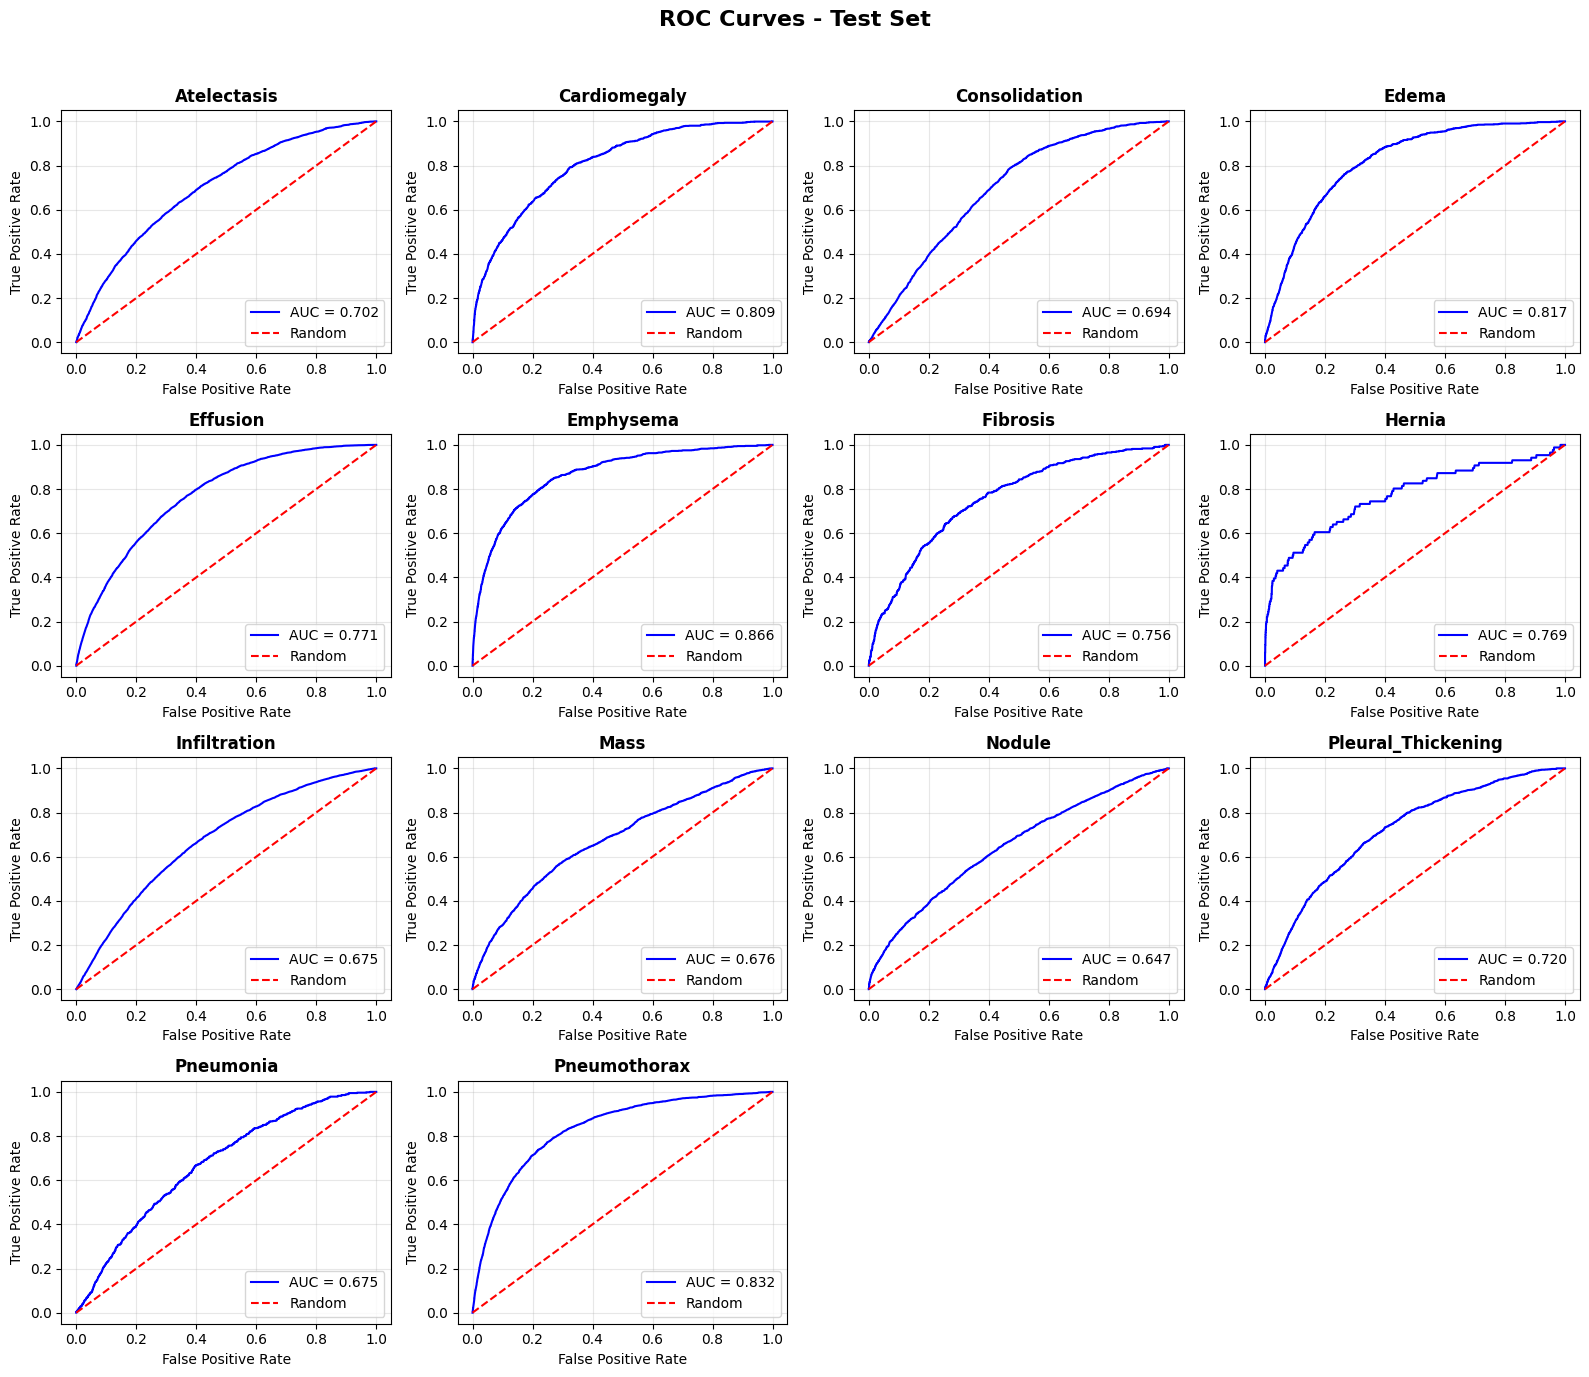


--- Precision-Recall Curves (Test Set) ---


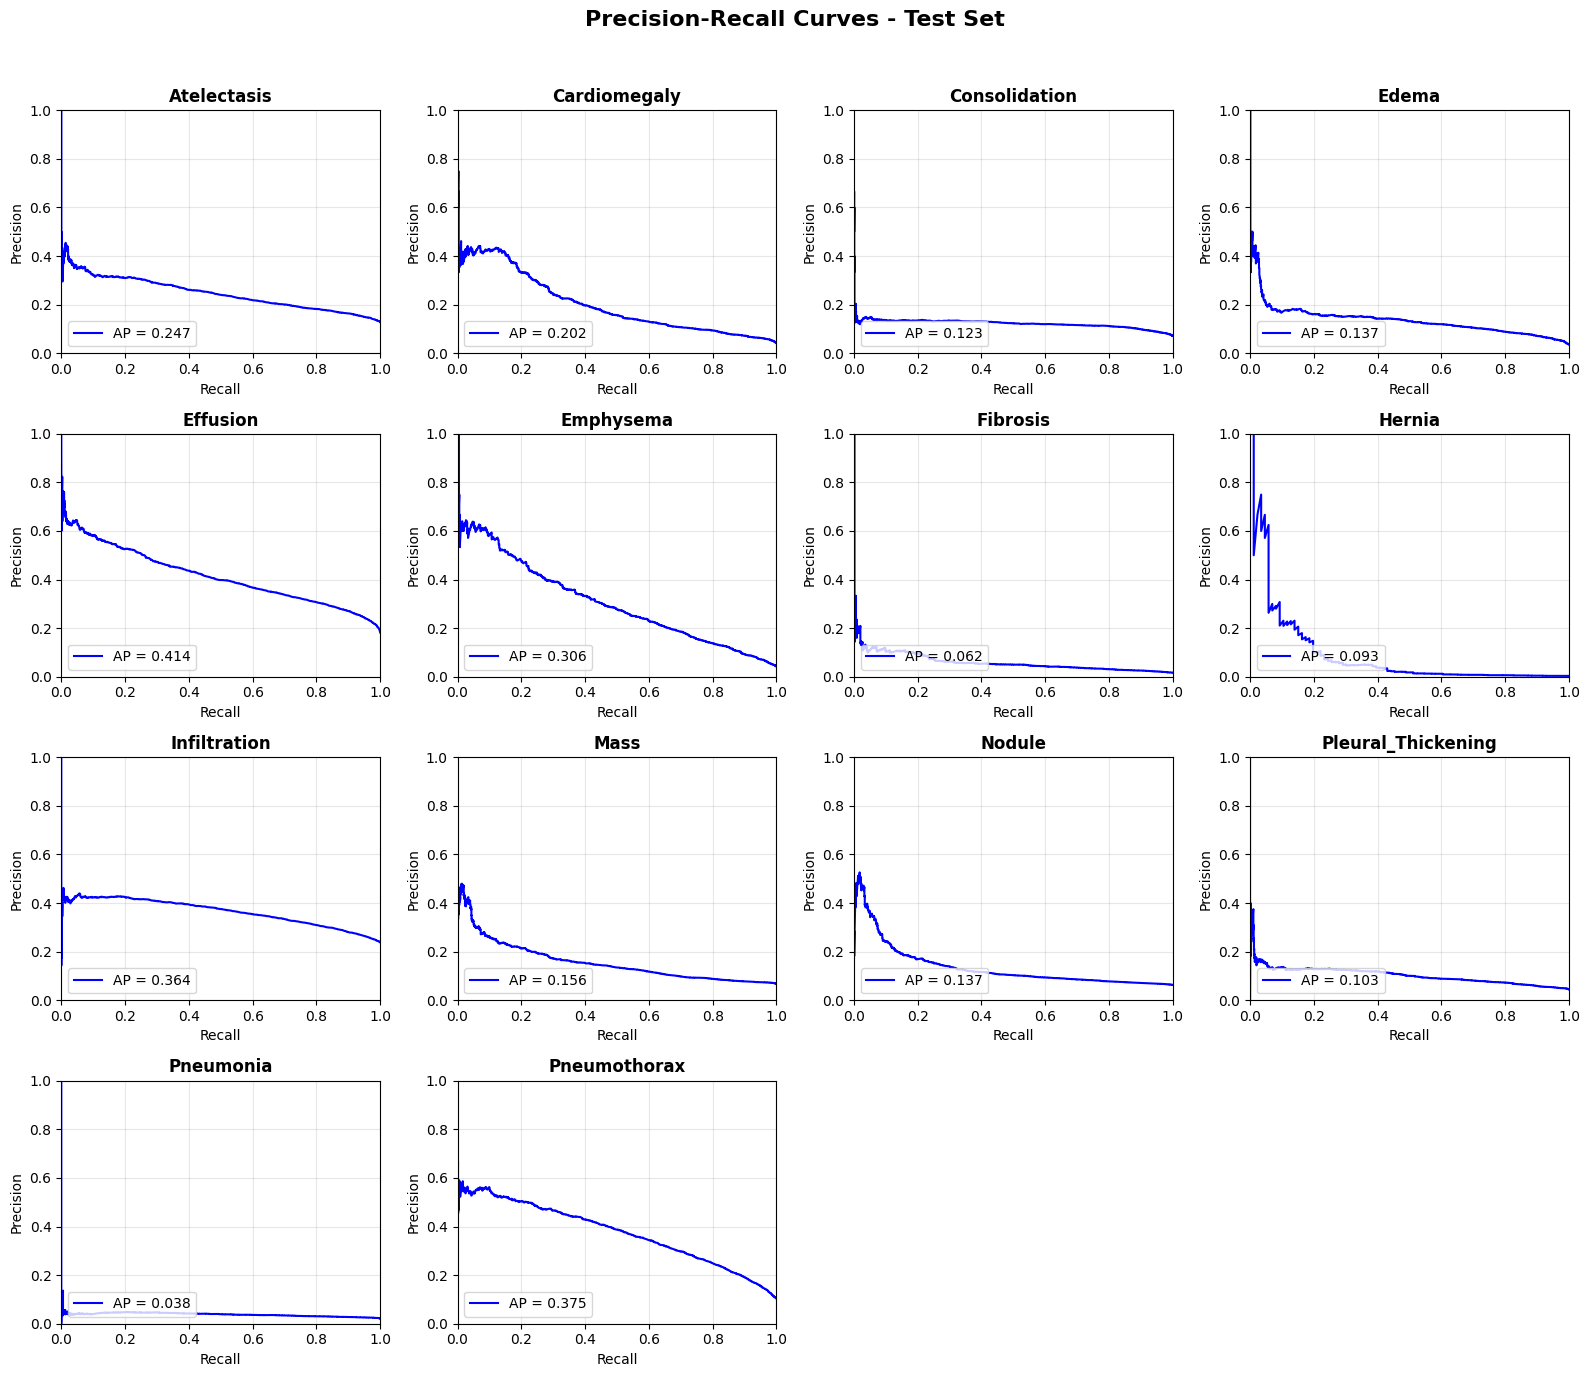


--- Class Accuracy (Test Set - Optimal Thresholds) ---


,Labels,Acc
0,Atelectasis,81.586967
1,Cardiomegaly,93.897484
2,Consolidation,86.157993
3,Edema,88.931864
4,Effusion,76.898734
5,Emphysema,94.264729
6,Fibrosis,95.096890
7,Hernia,99.609314
8,Infiltration,69.870292
9,Mass,90.580559



FINAL SUMMARY
Using Optimal Thresholds:
  Mean AUC-ROC: 74.36%
  Mean F1-Score: 24.61%
  Mean Precision: 23.59%
  Mean Recall: 28.30%

Using Fixed Threshold (0.5):
  Mean F1-Score: 8.54%
  Mean Precision: 34.60%
  Mean Recall: 6.30%


In [ ]:
# TEST DATASET COMPREHENSIVE EVALUATION
print('='*60)
print('TEST DATASET COMPREHENSIVE EVALUATION')
print('='*60)

print('\n' + '='*60)
print('COMPARISON: Fixed Threshold (0.5) vs Optimal Thresholds')
print('='*60)

# Method 1: Fixed threshold 0.5
print('\n--- Method 1: Fixed Threshold (0.5) ---')
test_results_fixed, test_preds, test_true = evaluate_model(
    test_loader, model, disease_cols, threshold=0.5, dataset_name='Test (Fixed 0.5)'
)

# Method 2: Optimal per-class thresholds
print('\n--- Method 2: Optimal Per-Class Thresholds ---')
test_results_optimal, _, _ = evaluate_model(
    test_loader, model, disease_cols, thresholds_dict=optimal_thresholds, dataset_name='Test (Optimal)'
)

# Side-by-side comparison
print('\n--- Comparison Summary ---')
comparison_df = pd.DataFrame({
    'Disease': disease_cols,
    'Fixed_F1': test_results_fixed['F1-Score'].values,
    'Optimal_F1': test_results_optimal['F1-Score'].values,
    'Fixed_Precision': test_results_fixed['Precision'].values,
    'Optimal_Precision': test_results_optimal['Precision'].values,
    'Fixed_Recall': test_results_fixed['Recall'].values,
    'Optimal_Recall': test_results_optimal['Recall'].values,
    'Optimal_Threshold': test_results_optimal['Threshold'].values
})
comparison_df['F1_Improvement'] = comparison_df['Optimal_F1'] - comparison_df['Fixed_F1']
display(comparison_df)

print(f'\nMean F1 Improvement: {comparison_df["F1_Improvement"].mean():.2f}%')

# Display detailed results with optimal thresholds
print('\n--- Detailed Test Results (Optimal Thresholds) ---')
display(test_results_optimal)

print('\n--- ROC Curves (Test Set) ---')
plot_roc_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set')

print('\n--- Precision-Recall Curves (Test Set) ---')
plot_precision_recall_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set')

print('\n--- Class Accuracy (Test Set - Optimal Thresholds) ---')
acc_list = class_accuracy(test_loader, model, thresholds_dict=optimal_thresholds)
acc_df = get_acc_data(disease_cols, acc_list)
display(acc_df)

# Summary comparison
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)
print(f'Using Optimal Thresholds:')
print(f'  Mean AUC-ROC: {test_results_optimal["AUC-ROC"].mean():.2f}%')
print(f'  Mean F1-Score: {test_results_optimal["F1-Score"].mean():.2f}%')
print(f'  Mean Precision: {test_results_optimal["Precision"].mean():.2f}%')
print(f'  Mean Recall: {test_results_optimal["Recall"].mean():.2f}%')
print(f'\nUsing Fixed Threshold (0.5):')
print(f'  Mean F1-Score: {test_results_fixed["F1-Score"].mean():.2f}%')
print(f'  Mean Precision: {test_results_fixed["Precision"].mean():.2f}%')
print(f'  Mean Recall: {test_results_fixed["Recall"].mean():.2f}%')
print('='*60)